# 21. Vector-state co-design for a self-reconfiguring robot

Examples 19 and 20 carried a single scalar between stages (a battery charge). Real reconfigurable systems carry a *state vector*. The Formula 1 seasonal co-design of Neumann, Zardini and colleagues carries two battery wear levels plus a regulatory flag; a self-reconfiguring modular robot on a multi-leg mission carries the accumulated wear of each drive module it can activate, plus a shared energy budget.

This notebook is the robot case, and it exercises the general **vector-state dynamic program**. A field robot reconfigures between three morphologies at each mission leg, drawing on two physical drive modules whose wear accumulates independently:

- **tracked**: uses the track module heavily. Low energy, high track wear.
- **wheeled**: uses the wheel module. Higher energy, low ops cost, high wheel wear.
- **hybrid**: splits load across both modules, wearing each a little.

The carried state is a vector of three axes (`track_wear`, `wheel_wear`, `energy`), and the optimal plan spreads wear across the two modules so neither hits its limit and forces an expensive fallback.


## Imports and module load

In [1]:
import importlib.util, os, sys
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

_spec = importlib.util.spec_from_file_location(
    'recon', os.path.join(PROJECT_ROOT, 'examples', '21_reconfigurable_robot.py'))
ex21 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(ex21)

from codesign import solve_vector_sequential, check_vector_monotonicity, sum_combine
print("Morphologies:", ", ".join(m.name for m in ex21.MORPHOLOGIES))
print(f"energy capacity {ex21.ENERGY_CAPACITY:.0f} (+{ex21.SOLAR_RECHARGE:.0f}/leg), "
      f"wear limit {ex21.WEAR_LIMIT:.0f} per module")


Morphologies: tracked, wheeled, hybrid
energy capacity 24 (+4/leg), wear limit 10 per module


## The morphologies, as an energy / ops / wear trade

Each morphology is a co-design problem returning the energy it draws, an operations-cost proxy, and the wear it applies to each module. Tracked and wheeled are deliberately *cost-incomparable* (tracked is cheaper on energy, wheeled on operations), so the mission has a genuine Pareto front rather than a single dominant plan.


In [2]:
print(f"{'morphology':<10} {'energy':>6} {'ops':>4} {'d_track':>8} {'d_wheel':>8}")
for m, spec in (("tracked",(2,4,3,0)),("wheeled",(4,2,0,3)),("hybrid",(3,3,1.5,1.5))):
    print(f"{m:<10} {spec[0]:>6} {spec[1]:>4} {spec[2]:>8} {spec[3]:>8}")


morphology energy  ops  d_track  d_wheel
tracked         2    4        3        0
wheeled         4    2        0        3
hybrid          3    3      1.5      1.5


## Solve the vector-state DP

`solve_vector_sequential` carries the full three-axis state vector on a `VectorStateGrid` (a product of three continuous axes), accumulating (energy, ops) on the antichain while the transition advances the wear and energy axes.


In [3]:
n_legs = 5
stages = ex21.build_mission(n_legs)
grid = ex21.VectorStateGrid([
    ex21.ContinuousAxis('track_wear', 0.0, ex21.WEAR_LIMIT, 11),
    ex21.ContinuousAxis('wheel_wear', 0.0, ex21.WEAR_LIMIT, 11),
    ex21.ContinuousAxis('energy', 0.0, ex21.ENERGY_CAPACITY, 13),
])
print(f"grid size: {len(grid)} state nodes")

res = solve_vector_sequential(
    stages, grid, cost_axes=['energy', 'ops'],
    initial_state={'track_wear': 0.0, 'wheel_wear': 0.0, 'energy': ex21.ENERGY_CAPACITY},
    combine=sum_combine)

front = sorted(((p['energy'], p['ops']) for p in res.value), key=lambda t: t[0])
print(f"\nMission Pareto front ({res.width} incomparable (energy, ops) totals):")
for e, o in front:
    print(f"   energy={e:6.1f}   ops={o:6.1f}")


grid size: 1573 state nodes



Mission Pareto front (5 incomparable (energy, ops) totals):
   energy=  13.0   ops=  17.0
   energy=  14.0   ops=  16.0
   energy=  15.0   ops=  15.0
   energy=  16.0   ops=  14.0
   energy=  17.0   ops=  13.0


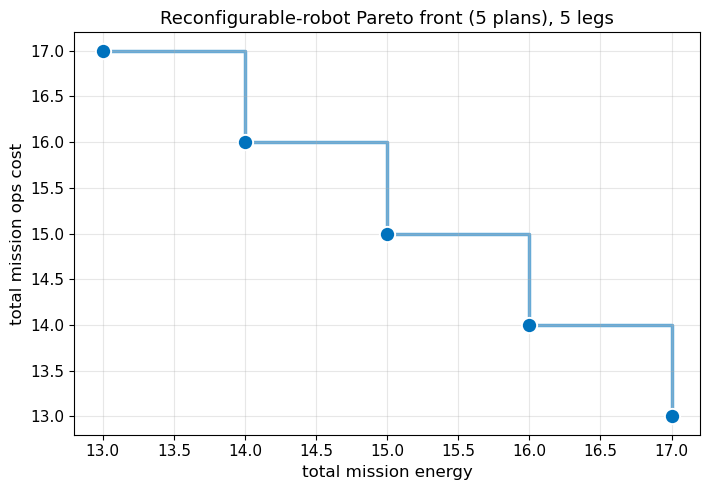

In [4]:
import matplotlib.pyplot as plt

BLUE = "#0072BD"
xs = [e for e, o in front]
ys = [o for e, o in front]

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.step(xs, ys, where="post", color=BLUE, lw=2.5, alpha=0.6, zorder=1)
ax.plot(xs, ys, "o", color=BLUE, markersize=11, zorder=3,
        markeredgecolor="white", markeredgewidth=1.4)
ax.set_xlabel("total mission energy", fontsize=12)
ax.set_ylabel("total mission ops cost", fontsize=12)
ax.set_title(f"Reconfigurable-robot Pareto front ({res.width} plans), {n_legs} legs",
             fontsize=13)
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()


## The three-axis carried state

The key point is that a scalar DP could not represent this problem: the value is parametrised by a *vector* of two wear levels plus energy. Below we confirm the monotonicity guard passes over the product order, so more spare wear budget and more energy never shrink the achievable front.


In [5]:
rep = check_vector_monotonicity(stages, grid, cost_axes=['energy', 'ops'])
print(rep)
print("value front monotone in the carried state vector:", rep.monotone_value_guaranteed)


VectorMonotonicityReport(H1=ok, H2=ok, value_monotone=guaranteed)
value front monotone in the carried state vector: True


## What the vector-state DP delivers

Each point on the front is a different morphology schedule across the five legs. The low-energy end leans on tracked (cheap energy), the low-ops end on wheeled (cheap operations), and the interior mixes so that neither module's wear reaches its limit. Reaching the fifth leg on a single morphology is infeasible (five wheeled legs would wear the wheel module past its limit), so the DP is forced to spread load, exactly the maintenance-aware behaviour an operator wants.

This is the structured multi-component state that the Formula 1 seasonal co-design carries (there: two batteries plus a regulatory flag; here: two drive modules plus energy). The single-axis case reduces to the scalar sequential DP of notebook 20, so the vector layer strictly generalises it.
